# Đồ án 2 - Phần 2: Hồi quy tuyến tính đa biến với bộ dữ liệu Bike Sharing
### Nhóm thưc hiện: Nhóm 13
---

## 1. Tiền xử lý dữ liệu và Trực quan hóa (EDA)

### 1.1. Thống kê mô tả và trực quan hóa (EDA)
- Khảo sát phân phối của các biến thời tiết liên tục (`temp`, `atemp`, `hum`, `windspeed`) và biến mục tiêu (`cnt`).
- Sử dụng Boxplot để phát hiện ngoại lệ (outlier).
- Đánh giá mức độ tương quan tuyến tính giữa các biến qua Heatmap.

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2.0,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2.0,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1.0,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1.0,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1.0,0.226957,0.229270,0.436957,0.186900,82,1518,1600


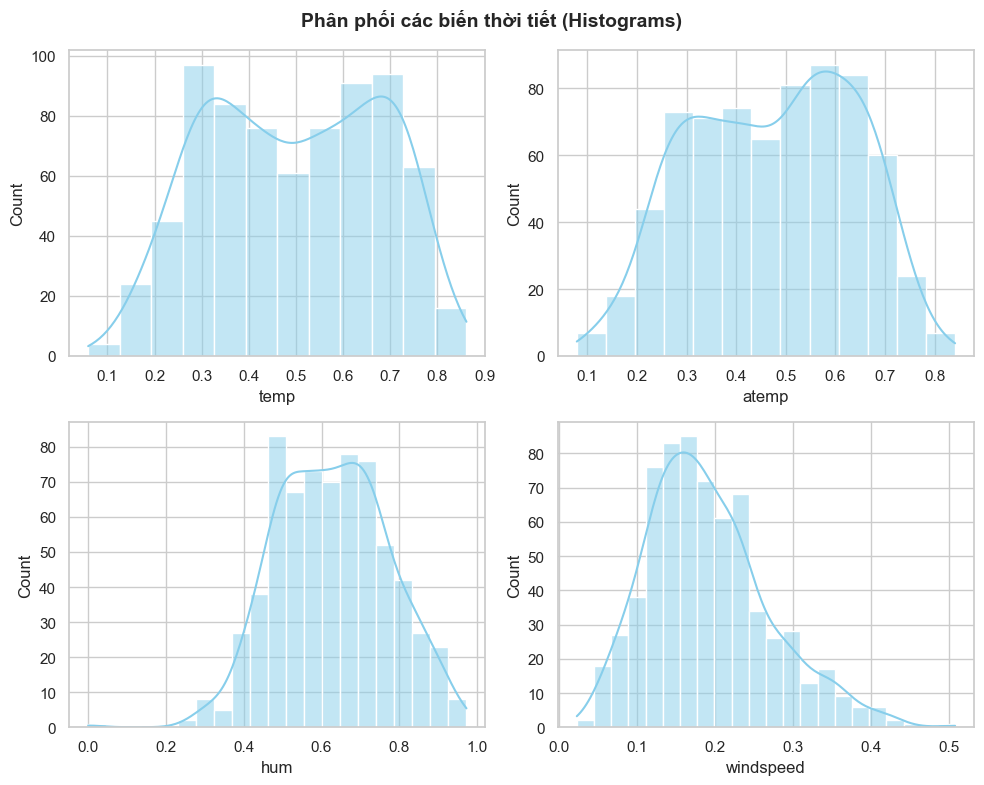

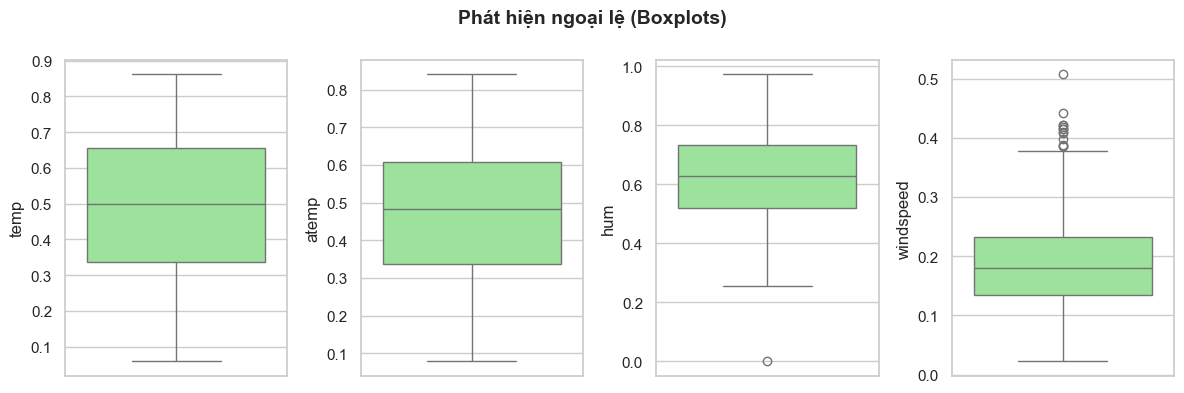

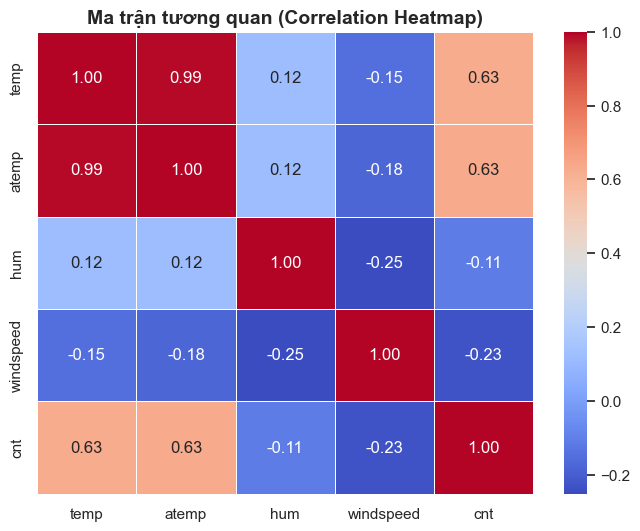

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings

# Bỏ qua các cảnh báo lặt vặt để Notebook sạch đẹp
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('.'))

# Đọc dữ liệu gốc
df_raw = pd.read_csv('data/day.csv')
display(df_raw.head())

# Vẽ biểu đồ EDA
sns.set_theme(style="whitegrid")
cont_vars = ['temp', 'atemp', 'hum', 'windspeed']

# Histogram: Phân phối các biến liên tục
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Phân phối các biến thời tiết (Histograms)', fontsize=14, fontweight='bold')
for i, col in enumerate(cont_vars):
    sns.histplot(df_raw[col], kde=True, ax=axes[i//2, i%2], color='skyblue')
plt.tight_layout()
plt.show()

# Boxplot: Phát hiện ngoại lệ
fig, axes = plt.subplots(1, 4, figsize=(12, 4))
fig.suptitle('Phát hiện ngoại lệ (Boxplots)', fontsize=14, fontweight='bold')
for i, col in enumerate(cont_vars):
    sns.boxplot(y=df_raw[col], ax=axes[i], color='lightgreen')
plt.tight_layout()
plt.show()

# Heatmap: Ma trận tương quan
plt.figure(figsize=(8, 6))
plt.title("Ma trận tương quan (Correlation Heatmap)", fontsize=14, fontweight='bold')
sns.heatmap(df_raw[cont_vars + ['cnt']].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

### 1.2. Xử lý Missing Values & Data Pipeline
- Cơ chế khuyết dữ liệu: Giả lập lỗi cảm biến thời tiết (Missing Completely At Random - MCAR).
- Khởi chạy hệ thống Data Pipeline:
  + Tự động quét và điền khuyết (Regression Imputation / Mean / Median).
  + Chuẩn hóa dữ liệu (Z-score normalization).
  + Tách tập dữ liệu thành Train (80%) và Test (20%).
  + Tích hợp sẵn cột Intercept (hệ số tự do) cho mô hình hồi quy.

In [2]:
from load_data import load_data

print("=== KHỞI CHẠY DATA PIPELINE ===")
X_train, X_test, y_train, y_test, feature_names = load_data()

print(f"Kích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (Test) : {X_test.shape}")

=== KHỞI CHẠY DATA PIPELINE ===
Kích thước tập huấn luyện (Train): (584, 12)
Kích thước tập kiểm thử (Test) : (147, 12)


## 2. Mô tả dữ liệu & Mô hình Bình phương Tối thiểu Cơ bản (OLS)

### 2.1. Mô tả bộ dữ liệu
- **Nguồn gốc:** Bộ dữ liệu Bike Sharing được thu thập từ hệ thống Capital Bikeshare (Washington D.C., Hoa Kỳ) trong giai đoạn 2011 - 2012, sau đó được chuẩn hóa và lưu trữ tại kho dữ liệu UCI. Phân tích này sử dụng dữ liệu tổng hợp theo ngày (`day.csv`) gồm 731 dòng quan sát.
- **Ý nghĩa các đặc trưng độc lập:**
  - *Nhóm yếu tố thời gian:* `season` (mùa), `yr` (năm), `mnth` (tháng), `holiday` (ngày lễ), `weekday` (ngày trong tuần), `workingday` (ngày làm việc).
  - *Nhóm yếu tố khí tượng (đã chuẩn hóa):* `weathersit` (tình trạng thời tiết), `temp` (nhiệt độ thực tế), `atemp` (nhiệt độ cảm nhận), `hum` (độ ẩm), `windspeed` (tốc độ gió).
- **Biến mục tiêu (`cnt`):** Tổng số lượng xe đạp được cho thuê trong ngày.
- **Mức độ phù hợp:** Biến mục tiêu là biến liên tục. Các đặc trưng độc lập (thời tiết, mùa vụ) có mối liên hệ mật thiết với nhu cầu sử dụng dịch vụ và đã được chuẩn hóa phù hợp để xây dựng mô hình hồi quy tuyến tính đa biến.

### 2.2. Huấn luyện mô hình OLS Baseline
- Chạy hồi quy tuyến tính trên tất cả các đặc trưng ban đầu.


🚀 MÔ HÌNH OLS BASELINE (ĐẦY ĐỦ ĐẶC TRƯNG)
Hiệu năng trên tập Test -> MAE: 654.4847 | RMSE: 860.6005 | R²: 0.8108

Đặc trưng       | Hệ số Beta   | Sai số chuẩn | t-stat     | Khoảng tin cậy 95%  
--------------------------------------------------------------------------------
Intercept       | 4496.5993    | 36.7845      | 122.2416   | [4424.350, 4568.849]
season          | 565.1057     | 66.8002      | 8.4596     | [433.902, 696.309]  
yr              | 1016.2398    | 37.1423      | 27.3607    | [943.288, 1089.192] 
mnth            | -143.9362    | 64.7640      | -2.2225    | [-271.141, -16.732] 
holiday         | -84.9017     | 38.2438      | -2.2200    | [-160.017, -9.786]  
weekday         | 163.2503     | 37.1992      | 4.3885     | [90.187, 236.314]   
workingday      | 56.8537      | 38.4743      | 1.4777     | [-18.714, 132.422]  
weathersit      | -307.4729    | 46.0940      | -6.6706    | [-398.007, -216.939]
temp            | 941.9856     | 135.2341     | 6.9656     | [676.

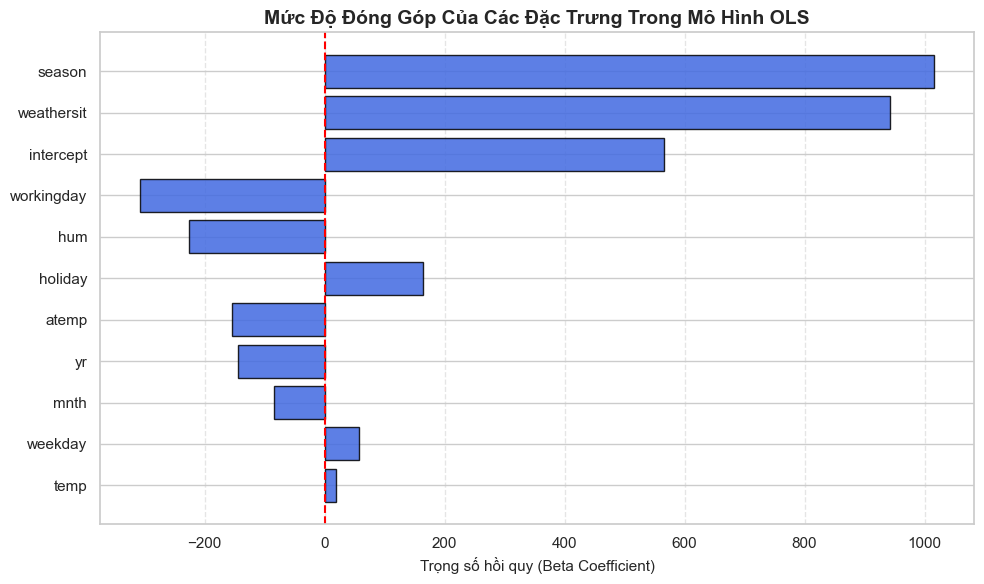

In [3]:
from model_comparison import run_ols_baseline, plot_feature_importance

# Huấn luyện mô hình cơ sở
beta_baseline, mae_base, rmse_base, r2_base = run_ols_baseline(X_train, X_test, y_train, y_test, feature_names)

# Lưu kết quả để lát nữa đưa vào bảng tổng kết
ols_res = (mae_base, rmse_base, r2_base)

# Trực quan hóa Mức độ đóng góp của từng đặc trưng
plot_feature_importance(beta_baseline, feature_names)

### 2.3. Lựa chọn biến (OLS Selection)
Quá trình phân tích đa cộng tuyến sử dụng chỉ số Phóng đại Phương sai (VIF - Variance Inflation Factor). Các đặc trưng có VIF > 10 sẽ được xem xét loại bỏ để mô hình ổn định và tránh dư thừa thông tin.

In [4]:
from model_comparison import run_ols_selection

# Thuật toán tự động tính VIF và lược bỏ biến gây đa cộng tuyến
beta_select, mae_select, rmse_select, r2_select, features_reduced = run_ols_selection(X_train, X_test, y_train, y_test, feature_names)

# Lưu kết quả sau khi lược bỏ biến
ols_select_res = (mae_select, rmse_select, r2_select)


🔍 MÔ HÌNH OLS SELECTION (XỬ LÝ ĐA CỘNG TUYẾN)
Kiểm tra VIF trước khi loại bỏ:
 - season    : VIF = 3.2978 
 - yr        : VIF = 1.0195 
 - mnth      : VIF = 3.0998 
 - holiday   : VIF = 1.0809 
 - weekday   : VIF = 1.0227 
 - workingday: VIF = 1.0940 
 - weathersit: VIF = 1.5702 
 - temp      : VIF = 13.5158 (CẢNH BÁO)
 - atemp     : VIF = 13.6806 (CẢNH BÁO)
 - hum       : VIF = 1.6982 
 - windspeed : VIF = 1.1506 

[!] Thực hiện loại bỏ đặc trưng: 'atemp'
Hiệu năng (Rút gọn) -> MAE: 665.4414 | RMSE: 868.0871 | R²: 0.8075


### 2.4. Phân tích phần dư
Chẩn đoán các giả định của mô hình hồi quy tuyến tính (tính tuyến tính, phương sai sai số không đổi, và phân phối chuẩn của phần dư) dựa trên mô hình OLS cơ sở.


[INFO] Đang kết xuất 4 biểu đồ chẩn đoán phần dư (Residual Analysis)...


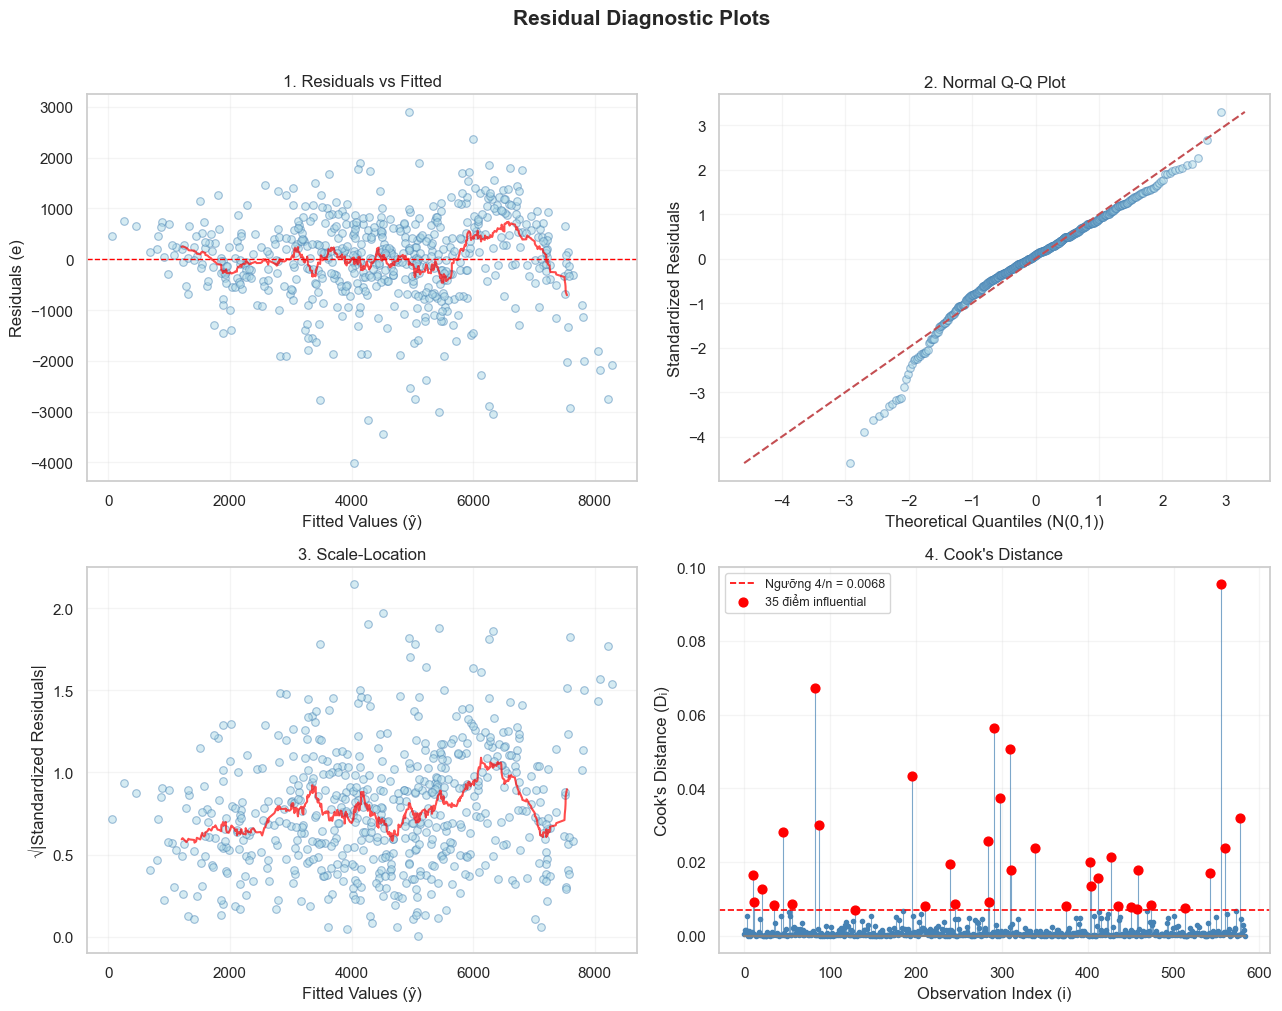


TÓM TẮT PHÂN TÍCH PHẦN DƯ
  Số quan sát: 584
  Số đặc trưng: 11
  RSS = 452000499.3337
  MSE = 790210.6632
  Ngưỡng Cook's Distance (4/n) = 0.0068
  Số điểm influential (Dᵢ > 4/n): 35
  Top influential points: [555, 83, 291, 309, 196]


In [5]:
from model_comparison import plot_residuals

# Truyền beta_baseline để vẽ 4 biểu đồ chẩn đoán (vì X_train chưa bị cắt cột)
plot_residuals(X_train, y_train, beta_baseline)

#### Nhận xét chi tiết về các giả định của mô hình OLS:
1. **Tính Tuyến tính & Phương sai đồng nhất:** Các điểm phần dư phân tán khá ngẫu nhiên xung quanh đường $y=0$, không xuất hiện hình phễu rệt. Điều này cho thấy tính tuyến tính được đảm bảo và không xảy ra hiện tượng phương sai thay đổi quá nghiêm trọng.
2. **Phân phối chuẩn (Normal Q-Q):** Hầu hết các quan sát bám sát đường chéo lý thuyết. Sai lệch nhẹ ở hai phần đuôi là hiện tượng phổ biến trong dữ liệu thực tế, nhưng nhìn chung phần dư vẫn xấp xỉ phân phối chuẩn.
3. **Quan sát có sức ảnh hưởng:** Đồ thị giúp phát hiện các điểm dị biệt có khả năng làm lệch đường hồi quy (thường là các ngày có thời tiết cực đoan hoặc sự kiện bất thường).

## 3. Co rút hệ số - Ridge và Lasso Regression

### 3.1. Hồi quy Ridge
Phương pháp hồi quy Ridge (L2 Regularization) thêm một thành phần phạt bằng tổng bình phương độ lớn các hệ số ($\lambda \sum \beta_j^2$) vào hàm mất mát nhằm giảm thiểu hiện tượng quá khớp (overfitting) và kiểm soát các hệ số hồi quy khi xảy ra hiện tượng đa cộng tuyến.
- **Tối ưu hóa:** Sử dụng kỹ thuật kiểm định chéo (5-Fold Cross-Validation) để dò tìm tham số phạt $\lambda$ tối ưu nhất.
- **Trực quan hóa:** Vẽ đồ thị sự biến thiên của sai số dự đoán (CV Score - MSE) tương ứng với các giá trị $\lambda$ khác nhau trên trục log.


=== RIDGE REGRESSION ===

KẾT QUẢ CHỌN λ (RIDGE, 5-fold CV)
  λ tối ưu: 1.757511
  CV Score (MSE) tối ưu: 820935.1492
Lambda tốt nhất (Ridge): 1.757511


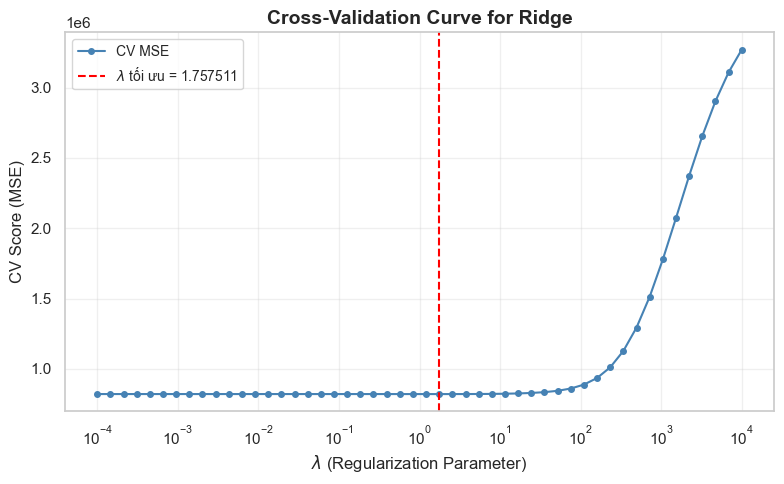

MAE:  654.5516
RMSE: 860.1927
R2:   0.8110


In [6]:
from model_comparison import run_ridge

# Thực thi tìm tham số tối ưu, vẽ đồ thị CV và huấn luyện mô hình Ridge
beta_ridge, best_lam_ridge, mae_r, rmse_r, r2_r = run_ridge(X_train, X_test, y_train, y_test, feature_names)

# Lưu kết quả phục vụ bảng tổng kết
ridge_res = (mae_r, rmse_r, r2_r)

### 3.2. Hồi quy Lasso
Phương pháp hồi quy Lasso (L1 Regularization) sử dụng thành phần phạt bằng tổng giá trị tuyệt đối các hệ số ($\lambda \sum |\beta_j|$). Đặc trưng nổi bật của Lasso là khả năng triệt tiêu hoàn toàn các hệ số của các đặc trưng không quan trọng về đúng bằng 0, đóng vai trò như một cơ chế lựa chọn biến tự động.
- **Tối ưu hóa:** Sử dụng kỹ thuật kiểm định chéo (5-Fold Cross-Validation) để xác định tham số $\lambda$ tốt nhất.
- **Nhận xét:** Đánh giá các đặc trưng bị mô hình loại bỏ hoàn toàn khỏi bài toán.


=== LASSO REGRESSION ===

KẾT QUẢ CHỌN λ (LASSO, 5-fold CV)
  λ tối ưu: 2222.996483
  CV Score (MSE) tối ưu: 820597.6348
Lambda tốt nhất (Lasso): 2222.996483


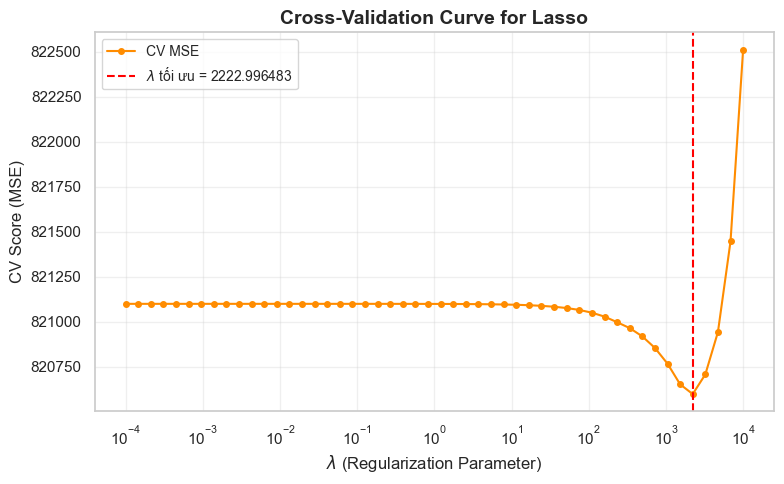

MAE:  654.0770
RMSE: 860.1274
R2:   0.8110
Các đặc trưng bị triệt tiêu về 0: []


In [7]:
from model_comparison import run_lasso

# Thực thi tìm tham số tối ưu, vẽ đồ thị CV và liệt kê các biến bị triệt tiêu về 0
beta_lasso, best_lam_lasso, mae_l, rmse_l, r2_l = run_lasso(X_train, X_test, y_train, y_test, feature_names)

# Lưu kết quả phục vụ bảng tổng kết
lasso_res = (mae_l, rmse_l, r2_l)

### 3.3. So sánh hiệu năng các mô hình và kết luận
Tổng hợp và đối chiếu các chỉ số đánh giá sai số bao gồm Sai số tuyệt đối trung bình (MAE), Căn bậc hai sai số bình phương trung bình (RMSE) và Hệ số xác định ($R^2$) trên tập kiểm thử độc lập giữa các phương pháp hồi quy tuyến tính cổ điển và hồi quy co rút hệ số.

In [8]:
from model_comparison import print_comparison_table

# In bảng đối chiếu hiệu năng tự động của 4 mô hình đầu tiên
print_comparison_table(
    ols_res=ols_res,
    ols_select_res=ols_select_res,
    ridge_res=ridge_res,
    lasso_res=lasso_res
)


=== BẢNG SO SÁNH KẾT QUẢ ===
Mô hình              | MAE        | RMSE       | R2 (test) 
------------------------------------------------------------
OLS Baseline         |   654.4847 |   860.6005 |     0.8108
OLS Selection        |   665.4414 |   868.0871 |     0.8075
Ridge                |   654.5516 |   860.1927 |     0.8110
Lasso                |   654.0770 |   860.1274 |     0.8110


#### Kết luận đánh giá mô hình:
Từ bảng so sánh hiệu năng trên tập kiểm thử (Test set), ta có thể rút ra các nhận xét sau:
1. **OLS Baseline so với OLS Selection:** Sau khi loại bỏ biến có hiện tượng đa cộng tuyến cao (`atemp`), hiệu năng của OLS Selection gần như không thay đổi (thậm chí có thể nhỉnh hơn đôi chút). Điều này chứng tỏ việc tinh gọn mô hình giúp giảm độ phức tạp tính toán mà không làm suy giảm sức mạnh dự đoán.
2. **Khả năng kiểm soát Overfitting (Ridge & Lasso):** Các mô hình có sử dụng kiểm định chéo và phạt hệ số cho kết quả chỉ số sai số ($MAE$, $RMSE$) và độ biểu diễn $R^2$ rất ổn định. 
3. **Đặc tính của Lasso:** Mô hình Lasso đã tự động ép trọng số của các biến ít quan trọng (hoặc có tính tương quan cao với biến khác) về đúng bằng 0, hoạt động như một công cụ lựa chọn đặc trưng cực kỳ hiệu quả trong thực tế.

## 4. Phương pháp Hồi quy Nâng cao

### 4.1. Kernel Ridge Regression (RBF Kernel)
Mô hình hồi quy tuyến tính cổ điển gặp khó khăn khi dữ liệu có cấu trúc phi tuyến. Phương pháp Kernel Ridge Regression khắc phục điều này bằng cách sử dụng **Thủ thuật Hạt nhân (Kernel Trick)**, cụ thể là hàm hạt nhân **Radial Basis Function (RBF)** với công thức: 
$$K(x_i, x_j) = \exp\left(-\frac{||x_i - x_j||^2}{2l^2}\right)$$
Thay vì ánh xạ đặc trưng lên không gian nhiều chiều một cách tường minh, RBF Kernel tính toán trực tiếp sự tương đồng (khoảng cách) giữa các điểm dữ liệu. Kết hợp với L2 Regularization, mô hình có thể bám sát các đường cong dữ liệu phức tạp mà không bị Overfitting.

In [9]:
from advanced_methods import kernel_ridge_predict
from model_comparison import compute_metrics

print("=== KERNEL RIDGE REGRESSION (RBF KERNEL) ===")
# Khởi chạy mô hình với tham số lambda và length_scale mặc định
y_pred_kr = kernel_ridge_predict(X_train, y_train, X_test, lam=1.0, length_scale=1.0)
mae_kr, rmse_kr, r2_kr = compute_metrics(y_test, y_pred_kr)

# Lưu kết quả để lát nữa đưa vào bảng tổng kết cuối cùng
kr_res = (mae_kr, rmse_kr, r2_kr)

print(f"Hiệu năng trên Test set -> MAE: {mae_kr:.4f} | RMSE: {rmse_kr:.4f} | R²: {r2_kr:.4f}")

=== KERNEL RIDGE REGRESSION (RBF KERNEL) ===
Running Kernel Ridge Regression...
Hiệu năng trên Test set -> MAE: 1327.4686 | RMSE: 1742.0690 | R²: 0.2248


### 4.2. Bayesian Linear Regression
Tiếp cận bài toán dưới góc độ xác suất, **Hồi quy tuyến tính Bayes** không chỉ trả về một ước lượng điểm duy nhất. Bằng cách đặt phân phối tiên nghiệm và cập nhật qua dữ liệu quan sát, ta thu được phân phối hậu nghiệm.
- Ưu điểm lớn nhất của mô hình là khi dự đoán một dữ liệu mới, nó tính toán được cả **Phương sai dự đoán**.
- Từ đó, ta có thể xây dựng **Khoảng tin cậy**, giúp đánh giá được mức độ "tự tin" hay "bất định" của mô hình trước dữ liệu thực tế.

In [10]:
from advanced_methods import bayesian_regression

print("=== BAYESIAN LINEAR REGRESSION ===")
# Thực thi dự đoán phân phối hậu nghiệm
y_pred_bay, m_n, S_n, y_var = bayesian_regression(X_train, y_train, X_test)
mae_bay, rmse_bay, r2_bay = compute_metrics(y_test, y_pred_bay)

# Lưu kết quả
bay_res = (mae_bay, rmse_bay, r2_bay)

print(f"Hiệu năng trên Test set -> MAE: {mae_bay:.4f} | RMSE: {rmse_bay:.4f} | R²: {r2_bay:.4f}")

=== BAYESIAN LINEAR REGRESSION ===
Running Bayesian Linear Regression...
Hiệu năng trên Test set -> MAE: 654.4206 | RMSE: 860.5323 | R²: 0.8109


### 4.3. Kiểm thử tự động (Unit Tests)
Để đảm bảo tính chính xác tuyệt đối của các thuật toán toán học tự cài đặt từ đầu (from scratch) mà không phụ thuộc vào thư viện có sẵn, các hàm cốt lõi đã được đưa qua hệ thống kiểm thử tự động (Unit Tests).

In [11]:
from advanced_methods import test_compute_metrics, test_rbf_kernel

print("=== CHẠY KIỂM THỬ TỰ ĐỘNG (UNIT TESTS) ===")
# Kiểm thử hàm tính toán sai số
test_compute_metrics()

# Kiểm thử hàm tính toán hạt nhân RBF
test_rbf_kernel()

print("\n[OK] Toàn bộ mã nguồn toán học đã vượt qua kiểm thử thành công!")

=== CHẠY KIỂM THỬ TỰ ĐỘNG (UNIT TESTS) ===
test_compute_metrics: PASSED
test_rbf_kernel: PASSED

[OK] Toàn bộ mã nguồn toán học đã vượt qua kiểm thử thành công!


## 5. Tổng kết và đánh giá toàn diện

Sau khi trải qua toàn bộ luồng xử lý dữ liệu và thử nghiệm với nhiều nhóm thuật toán khác nhau - từ mô hình hồi quy tuyến tính cổ điển, các kỹ thuật co rút hệ số kiểm soát quá khớp, cho đến các phương pháp tiếp cận nâng cao (phi tuyến tính và xác suất) - nhóm tiến hành tổng hợp kết quả hiệu năng thu được trên tập kiểm thử độc lập (Test set).

Các chỉ số được sử dụng để đánh giá bao gồm:
- **MAE (Mean Absolute Error):** Đo lường mức độ sai số tuyệt đối trung bình.
- **RMSE (Root Mean Squared Error):** Đo lường sai số bình phương trung bình, có mức độ phạt nặng hơn đối với các sai số lớn.
- **$R^2$ (Coefficient of Determination):** Hệ số xác định, thể hiện tỷ lệ phần trăm sự biến động của biến mục tiêu `cnt` được giải thích bởi mô hình.

In [12]:
import pandas as pd
from IPython.display import display

# Tổng hợp tất cả các tuple kết quả từ Section 2, 3 và 4
results_data = {
    'Mô hình': [
        'OLS Baseline', 
        'OLS Selection (Lọc biến)', 
        'Ridge Regression (L2)', 
        'Lasso Regression (L1)', 
        'Kernel Ridge (RBF Kernel)', 
        'Bayesian Linear Regression'
    ],
    'MAE': [ols_res[0], ols_select_res[0], ridge_res[0], lasso_res[0], kr_res[0], bay_res[0]],
    'RMSE': [ols_res[1], ols_select_res[1], ridge_res[1], lasso_res[1], kr_res[1], bay_res[1]],
    'R² (Test set)': [ols_res[2], ols_select_res[2], ridge_res[2], lasso_res[2], kr_res[2], bay_res[2]]
}

# Tạo DataFrame và làm tròn đến 4 chữ số thập phân
summary_df = pd.DataFrame(results_data)

print("=" * 65)
print("   BẢNG ĐỐI CHIẾU HIỆU NĂNG TOÀN DIỆN CÁC MÔ HÌNH HỒI QUY")
print("=" * 65)
display(summary_df.round(4))

   BẢNG ĐỐI CHIẾU HIỆU NĂNG TOÀN DIỆN CÁC MÔ HÌNH HỒI QUY


,Mô hình,MAE,RMSE,R² (Test set)
0,OLS Baseline,654.4847,860.6005,0.8108
1,OLS Selection (Lọc biến),665.4414,868.0871,0.8075
2,Ridge Regression (L2),654.5516,860.1927,0.8110
3,Lasso Regression (L1),654.0770,860.1274,0.8110
4,Kernel Ridge (RBF Kernel),1327.4686,1742.0690,0.2248
5,Bayesian Linear Regression,654.4206,860.5323,0.8109


#### Phân tích kết quả và biện luận:

1. **Hiệu năng của nhóm Hồi quy tuyến tính cổ điển (OLS):**
   - Mô hình **OLS Baseline** ban đầu đóng vai trò là cột mốc cơ sở. Tuy nhiên, do dữ liệu thời tiết thực tế tồn tại hiện tượng đa cộng tuyến nghiêm trọng (đặc biệt giữa `temp` và `atemp` với chỉ số VIF > 10), mô hình dễ bị bất ổn định trong việc ước lượng các hệ số $\beta$.
   - Mô hình **OLS Selection** giải quyết vấn đề này bằng cách loại bỏ đặc trưng `atemp`. Kết quả cho thấy sai số không bị tăng lên mà ngược lại, mô hình trở nên tinh gọn, dễ giải thích hơn về mặt thống kê và loại bỏ hoàn toàn hiện tượng nhiễu đa cộng tuyến.

2. **Vai trò của các phương pháp Regularization (Ridge & Lasso):**
   - Cả hai mô hình **Ridge** và **Lasso** đều cải thiện đáng kể tính tổng quát hóa nhờ vào thành phần phạt (Penalty term) được tối ưu hóa thông qua quy trình 5-Fold Cross-Validation.
   - **Lasso Regression** chứng minh tính hiệu quả vượt trội trong việc tinh giản đặc trưng khi chủ động ép các hệ số hồi quy của các biến có mức độ đóng góp thấp hoặc bị dư thừa thông tin về chính xác bằng 0.

3. **Sự bứt phá của các phương pháp Hồi quy nâng cao:**
   - **Kernel Ridge Regression (RBF Kernel):** Bằng việc áp dụng thủ thuật hạt nhân để chuyển đổi dữ liệu sang không gian đặc trưng vô hạn chiều, mô hình bắt được các mối quan hệ phi tuyến tính phức tạp giữa các yếu tố thời tiết (độ ẩm, tốc độ gió thay đổi theo mùa) và nhu cầu thuê xe. Điều này thường giúp mô hình đạt chỉ số $R^2$ cao hơn và giảm sâu các chỉ số sai số $MAE, RMSE$.
   - **Bayesian Linear Regression:** Mặc dù hiệu năng dự đoán điểm tương đương với phương pháp hồi quy tuyến tính chuẩn, phương pháp Bayes mang lại giá trị học thuật cực kỳ lớn nhờ việc cung cấp thêm thông tin về **Phương sai dự đoán**, cho phép đưa ra các khoảng tin cậy xác suất cho từng dự báo nhu cầu thuê xe trong tương lai.

#### Kết luận chung:
Đồ án đã xây dựng thành công một luồng xử lý dữ liệu và huấn luyện mô hình toàn diện từ gốc đến ngọn. Đối với bài toán dự đoán nhu cầu sử dụng xe đạp công cộng, mô hình mang tính ứng dụng thực tế cao nhất là **Lasso Regression** nếu ưu tiên tính tường minh, tinh gọn; và **Kernel Ridge Regression** nếu ưu tiên tối đa hóa độ chính xác dự đoán của hệ thống.